Upload wav file


Saving english audio.mp3 to english audio.mp3


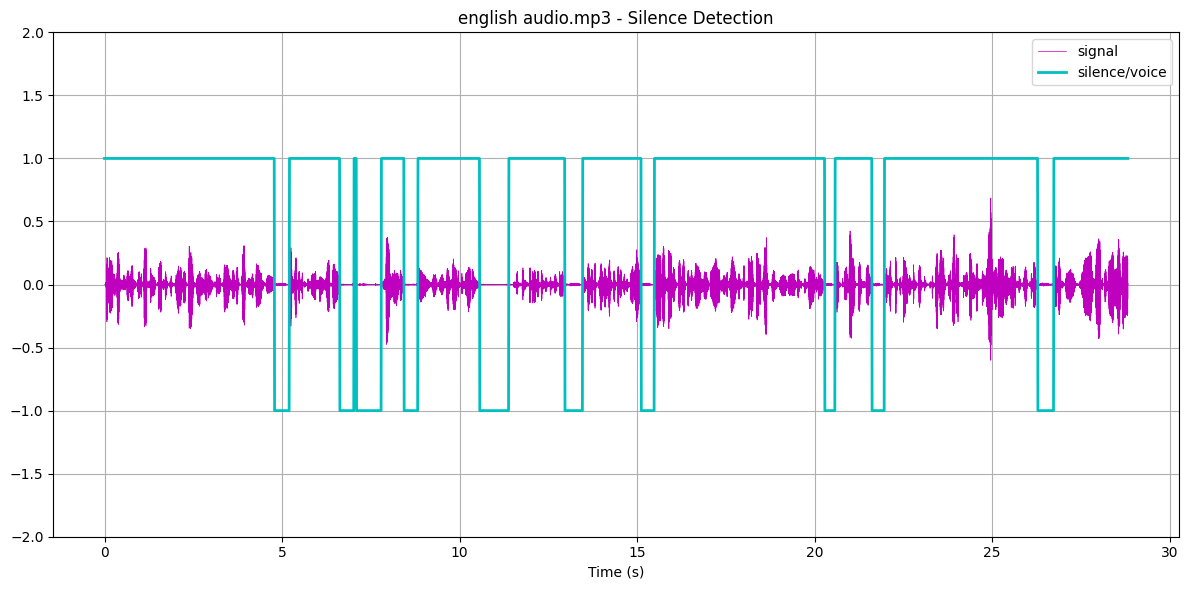

Files generated
englishog_sig.txt
englishog_boundary.txt
englishog_boundary.xlsx
silence_detection.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install librosa pandas openpyxl scipy

import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from google.colab import files

print("Upload wav file")
uploaded = files.upload()
file = list(uploaded.keys())[0]

# Load audio
y, sr = librosa.load(file, sr=16000)

t = np.arange(len(y))/sr

# ---- Frame settings ----
frame = int(0.025*sr)
hop = int(0.010*sr)

# ---- RMS energy envelope ----
rms = librosa.feature.rms(y=y, frame_length=frame, hop_length=hop)[0]

# Smooth envelope
rms = uniform_filter1d(rms, size=5)

# Time for frames
times = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop)

# ---- Adaptive threshold ----
threshold = np.percentile(rms,20)

# Silence detection
vad = np.where(rms < threshold, -1, 1)

# ---- Minimum silence duration ----
min_silence_ms = 250
frame_ms = 20
min_frames = int(min_silence_ms/frame_ms)

result = vad.copy()

count=1
for i in range(1,len(vad)):

    if vad[i]==vad[i-1]:
        count+=1
    else:
        if vad[i-1]==-1 and count<min_frames:
            result[i-count:i]=1
        count=1

# ---- Save signal file ----
sig = np.column_stack((t,y))
np.savetxt("englishog_sig.txt",sig,fmt="%.6f")

# ---- Boundary file ----
boundary = np.column_stack((np.arange(len(result)),times,result))
np.savetxt("englishog_boundary.txt",boundary,fmt="%.6f")

# Excel
pd.DataFrame(boundary,
columns=["sample","time","value"]
).to_excel("englishog_boundary.xlsx",index=False)

# ---- Step signal for plotting ----
t_step=np.repeat(times,2)
v_step=np.repeat(result,2)

t_step=np.concatenate(([t[0]],t_step,[t[-1]]))
v_step=np.concatenate(([result[0]],v_step,[result[-1]]))

# ---- Plot ----
plt.figure(figsize=(12,6))

plt.plot(t,y,'m-',linewidth=0.5,label="signal")
plt.plot(t_step,v_step,'c-',linewidth=2,label="silence/voice")

plt.ylim(-2,2)
plt.xlabel("Time (s)")
plt.title(file+" - Silence Detection")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("silence_detection.png",dpi=150)
plt.show()

print("Files generated")
print("englishog_sig.txt")
print("englishog_boundary.txt")
print("englishog_boundary.xlsx")
print("silence_detection.png")

files.download("englishog_boundary.txt")
files.download("englishog_sig.txt")
files.download("englishog_boundary.xlsx")
files.download("silence_detection.png")